# Analyse Exploratoire des Données (EDA) – Obesity Dataset

L’objectif de ce notebook est de réaliser une analyse exploratoire du dataset
sur l’obésité.

Cette analyse vise à :

- Comprendre la structure du dataset
- Détecter les valeurs manquantes
- Analyser la distribution des classes d’obésité
- Étudier les corrélations entre variables
- Visualiser les distributions des variables
- Détecter les valeurs aberrantes (outliers)

## Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour la manipulation des données
et la visualisation.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## Chargement du dataset

Le dataset est chargé à partir d’un fichier CSV contenant les informations
liées aux habitudes alimentaires, au mode de vie et au niveau d’obésité.


In [16]:
df = pd.read_csv("../data/ObesityDataSet_raw_and_data_sinthetic.csv")

df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Aperçu général du dataset

Nous examinons la taille du dataset, les types de variables et les statistiques
descriptives.


In [17]:
df.shape

(2111, 17)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

## Analyse des valeurs manquantes

Nous vérifions si le dataset contient des valeurs manquantes pouvant
affecter l'analyse.


In [19]:
df.isnull().sum()


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

## Distribution des classes d'obésité

La variable cible du dataset est **NObeyesdad** qui représente le niveau
d'obésité des individus.
Nous analysons la distribution des différentes classes.


In [20]:
df['NObeyesdad'].value_counts()


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

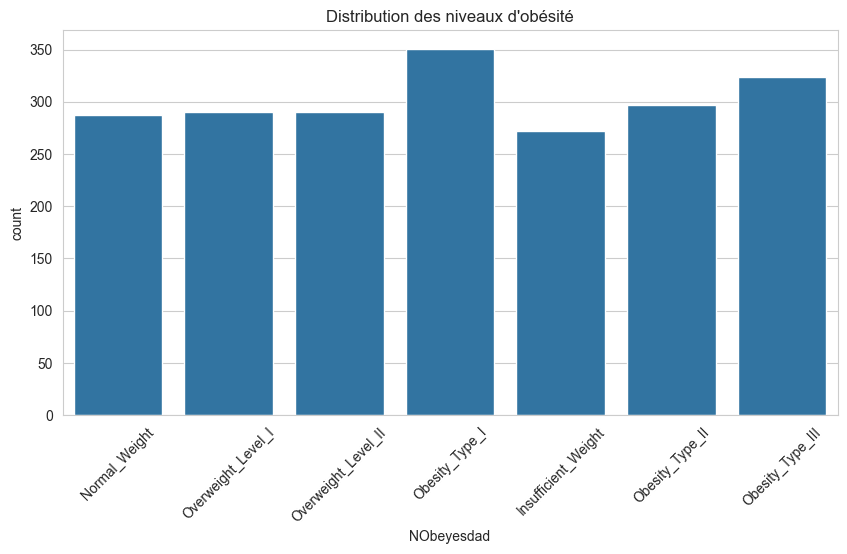

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='NObeyesdad')
plt.xticks(rotation=45)
plt.title("Distribution des niveaux d'obésité")
plt.show()


## Analyse des corrélations

La matrice de corrélation permet d’identifier les relations entre les
variables numériques du dataset.


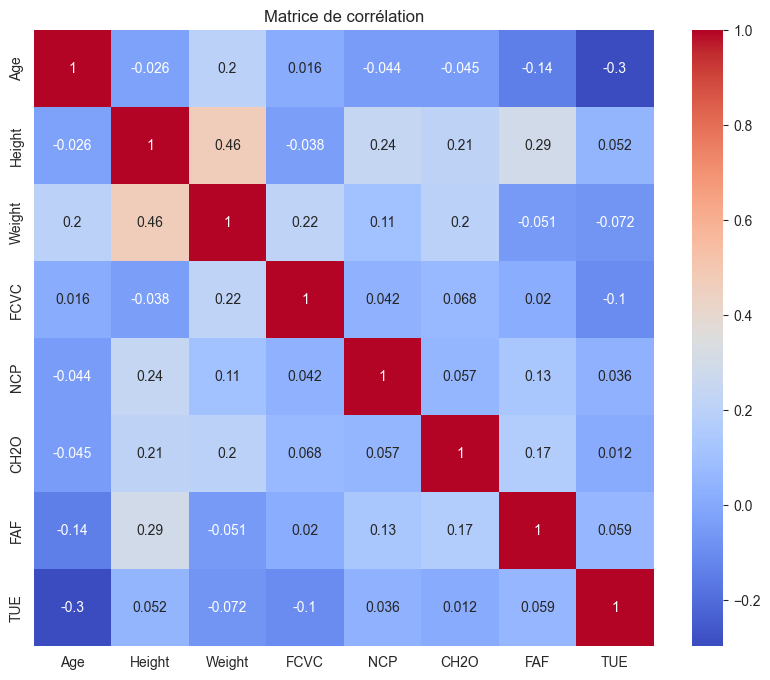

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


## Distribution des variables numériques

Les histogrammes permettent d'observer la distribution des variables
numériques du dataset.


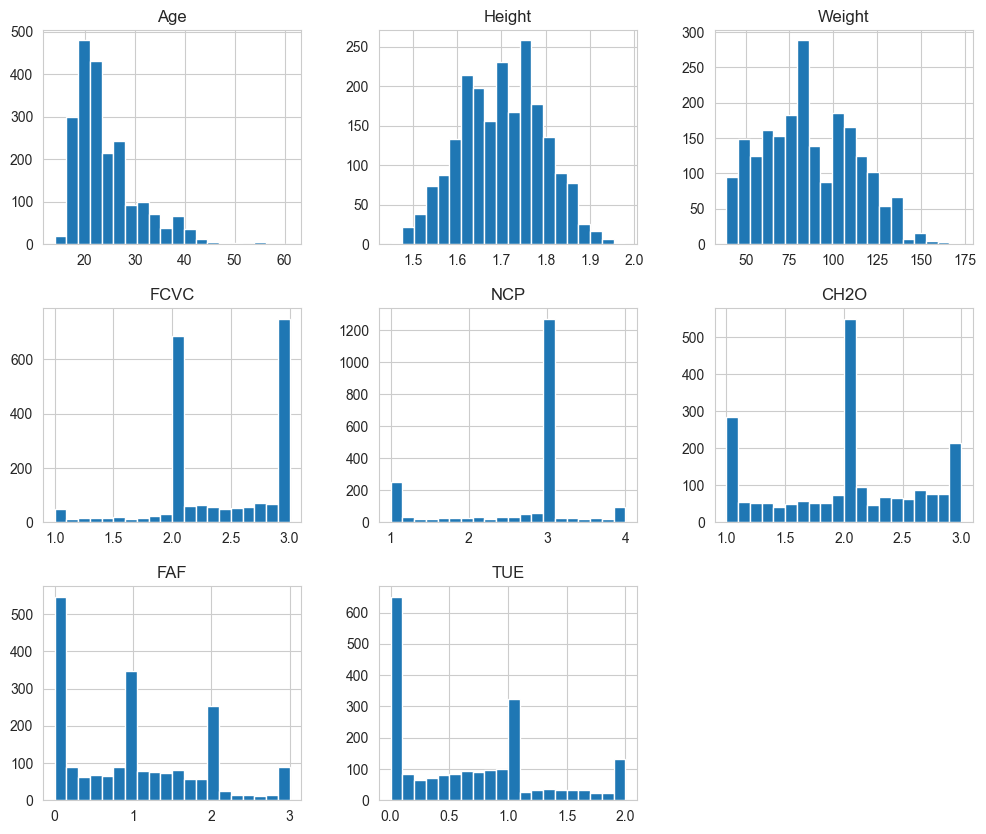

In [23]:
df.hist(figsize=(12,10), bins=20)
plt.show()


## Détection des valeurs aberrantes (Outliers)

Les boxplots permettent d’identifier les valeurs extrêmes dans les
variables numériques.


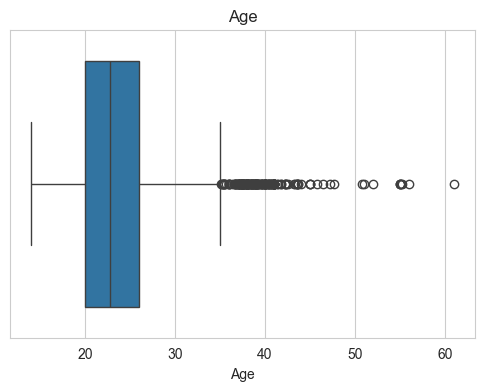

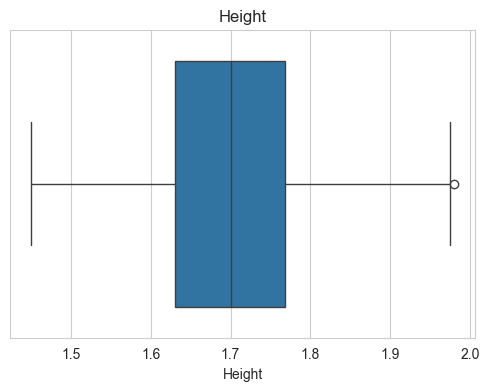

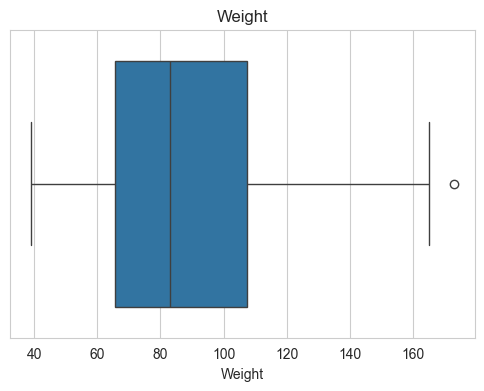

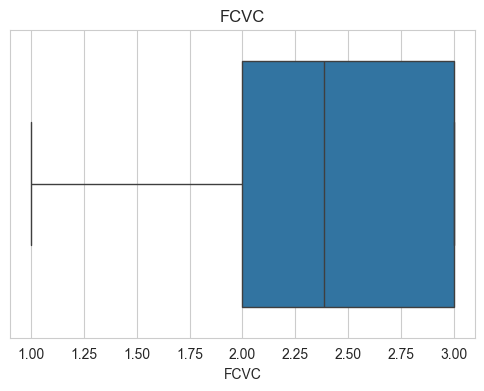

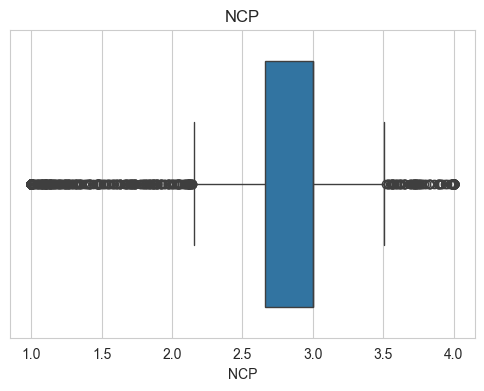

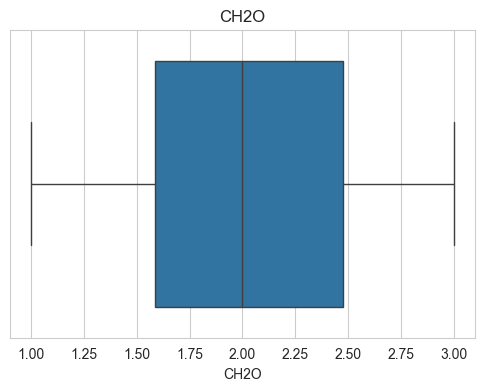

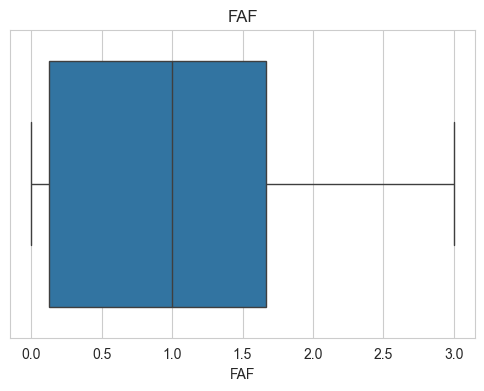

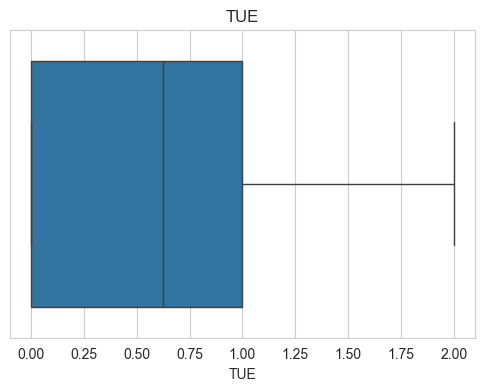

In [24]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


## Conclusion

L’analyse exploratoire du dataset a permis de tirer plusieurs observations :

- Le dataset contient 2111 observations et 17 variables.
- Aucune valeur manquante n’a été détectée.
- La variable cible comporte 7 classes de niveaux d’obésité.
- Les corrélations permettent d’identifier certaines relations entre
  variables liées au mode de vie et à l’obésité.
- Des valeurs aberrantes peuvent être observées dans certaines variables.

Ces observations serviront de base pour les étapes suivantes du projet,
notamment la préparation des données et la modélisation.
